In [1]:
import pandas as pd
df = pd.read_csv("bank.csv")
print(df.shape)
df.head()  

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [5]:
missing_values = df.isnull().sum()
print("Missing values per column:")
missing_values

Missing values per column:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [6]:
duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [7]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (11162, 17)


In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [9]:
df["deposit"].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [10]:
target_percentage = df["deposit"].value_counts(normalize=True) * 100

target_percentage

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

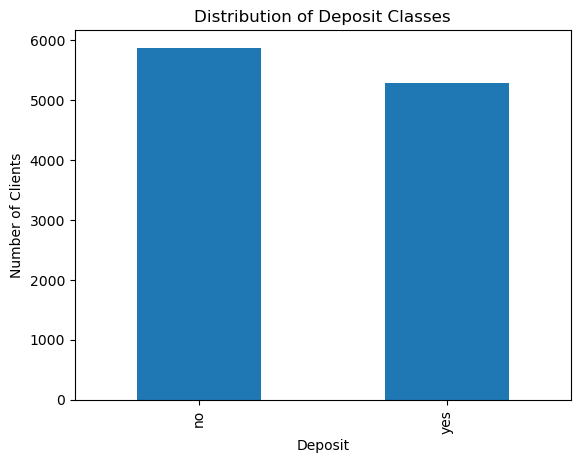

In [11]:
df["deposit"].value_counts().plot(kind="bar")

plt.title("Distribution of Deposit Classes")
plt.xlabel("Deposit")
plt.ylabel("Number of Clients")
plt.show()

In [12]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numeric columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numeric columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [13]:
for column in categorical_columns:
    print("=" * 50)
    print(column)
    print(df[column].value_counts().head(10))

job
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
Name: count, dtype: int64
marital
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
education
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
default
default
no     10994
yes      168
Name: count, dtype: int64
housing
housing
no     5881
yes    5281
Name: count, dtype: int64
loan
loan
no     9702
yes    1460
Name: count, dtype: int64
contact
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64
month
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
Name: count, dtype: int64
poutcome
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name:

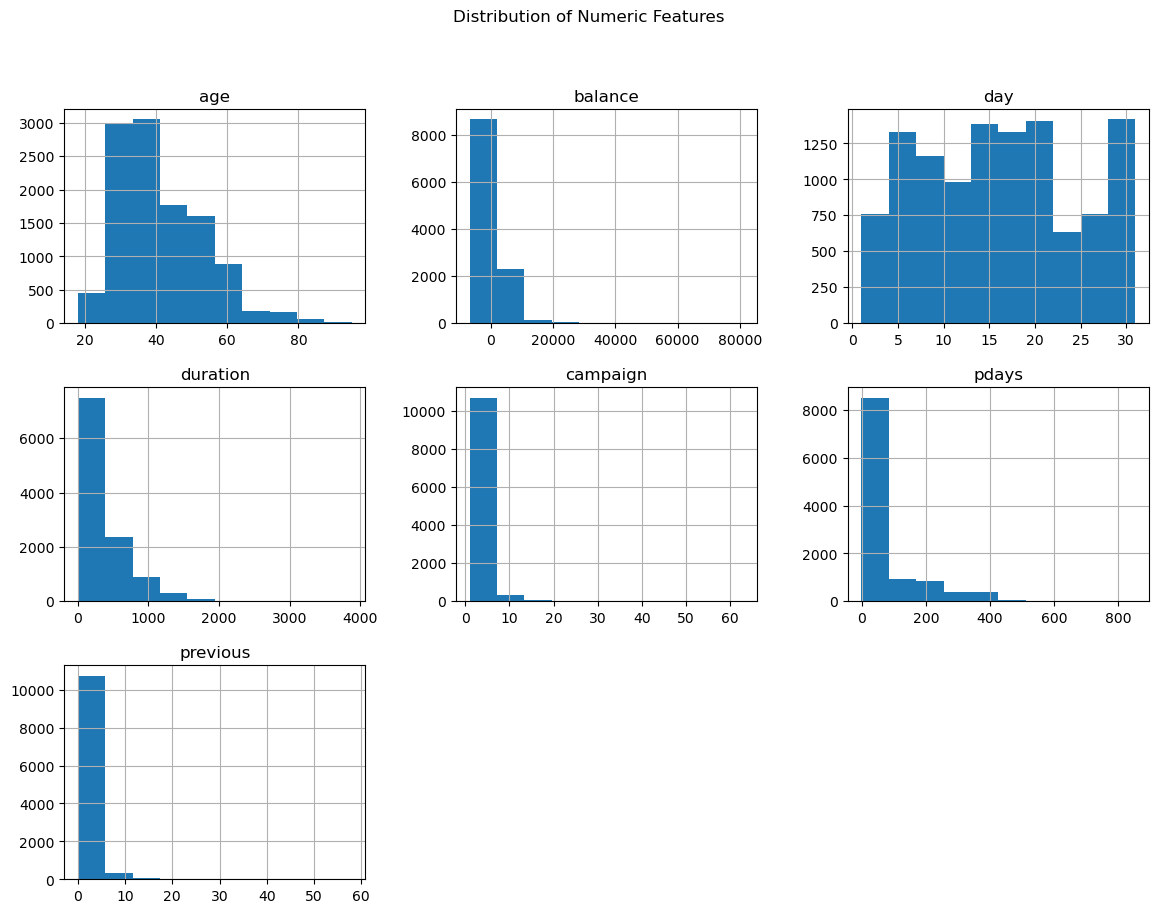

In [14]:
df[numeric_columns].hist(figsize=(14, 10))

plt.suptitle("Distribution of Numeric Features")
plt.show()

In [15]:
correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.112300,-0.000762,0.000189,-0.005278,0.002774,0.020169
balance,0.112300,1.000000,0.010467,0.022436,-0.013894,0.017411,0.030805
day,-0.000762,0.010467,1.000000,-0.018511,0.137007,-0.077232,-0.058981
duration,0.000189,0.022436,-0.018511,1.000000,-0.041557,-0.027392,-0.026716
campaign,-0.005278,-0.013894,0.137007,-0.041557,1.000000,-0.102726,-0.049699
pdays,0.002774,0.017411,-0.077232,-0.027392,-0.102726,1.000000,0.507272
previous,0.020169,0.030805,-0.058981,-0.026716,-0.049699,0.507272,1.000000


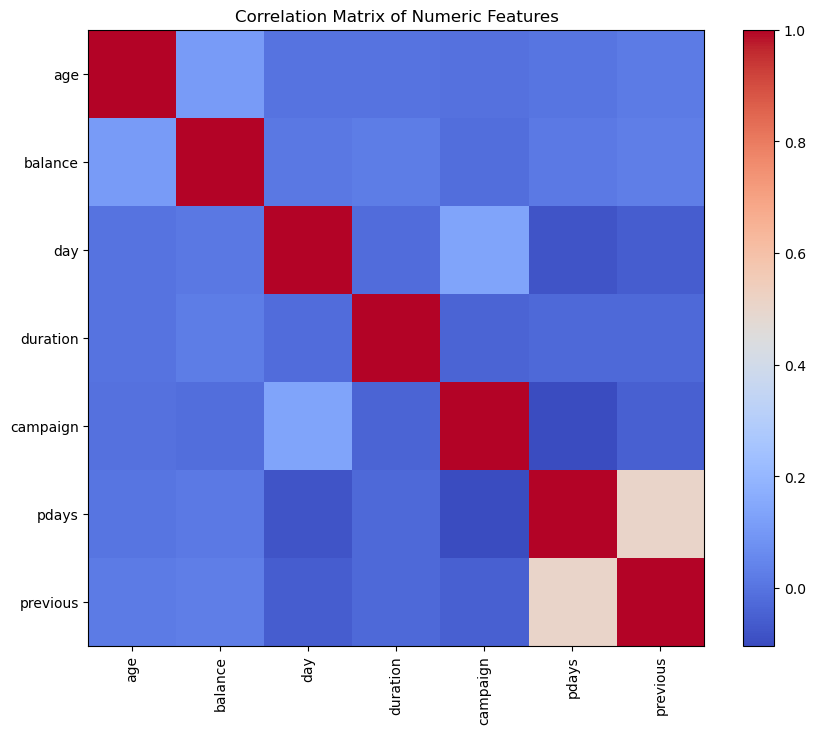

In [16]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [17]:
target = "deposit"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11162, 16)
y shape: (11162,)


In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded target example:", y_encoded[:10])

Classes: ['no' 'yes']
Encoded target example: [1 1 1 1 1 1 1 1 1 1]


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8929, 16)
X_test shape: (2233, 16)
y_train shape: (8929,)
y_test shape: (2233,)


In [20]:
print("Train target distribution:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

Train target distribution:
0    52.615074
1    47.384926
Name: proportion, dtype: float64

Test target distribution:
0    52.619794
1    47.380206
Name: proportion, dtype: float64


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numeric features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numeric features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [23]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [24]:
baseline_results = []
baseline_pipelines = {}

for name, model in baseline_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    baseline_pipelines[name] = pipeline
    
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.826243,0.827789,0.799622,0.813462
1,KNN,0.817286,0.819882,0.787335,0.803279
2,Decision Tree,0.794447,0.789372,0.772212,0.780698
3,Random Forest,0.862069,0.830106,0.891304,0.859617


In [25]:
baseline_results_df.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
3,Random Forest,0.862069,0.830106,0.891304,0.859617
0,Logistic Regression,0.826243,0.827789,0.799622,0.813462
1,KNN,0.817286,0.819882,0.787335,0.803279
2,Decision Tree,0.794447,0.789372,0.772212,0.780698


In [26]:
for name, pipeline in baseline_pipelines.items():
    y_pred = pipeline.predict(X_test)
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Logistic Regression
              precision    recall  f1-score   support

          no       0.82      0.85      0.84      1175
         yes       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.83      2233
weighted avg       0.83      0.83      0.83      2233

KNN
              precision    recall  f1-score   support

          no       0.82      0.84      0.83      1175
         yes       0.82      0.79      0.80      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233

Decision Tree
              precision    recall  f1-score   support

          no       0.80      0.81      0.81      1175
         yes       0.79      0.77      0.78      1058

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79   

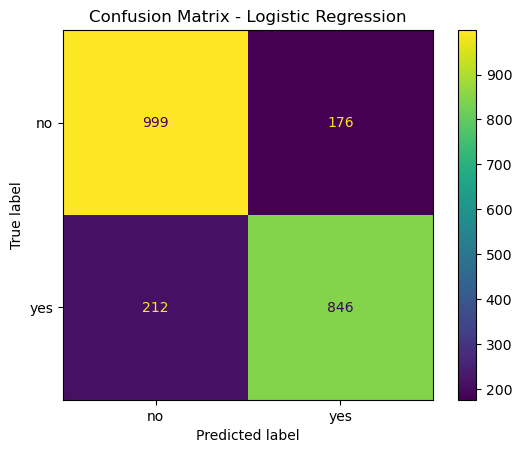

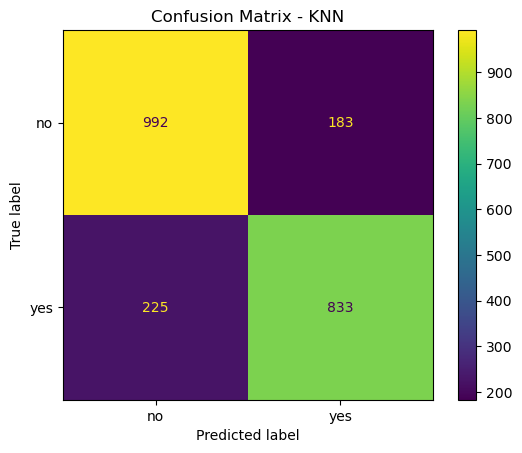

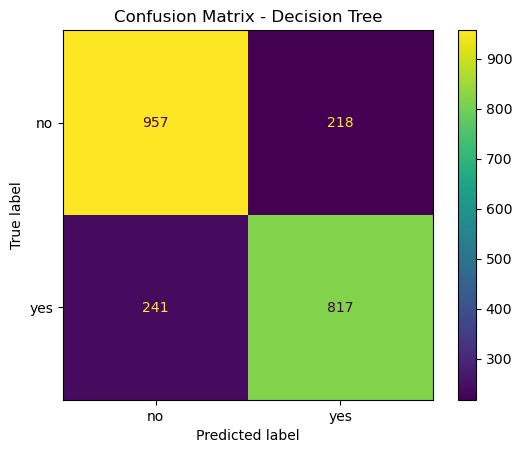

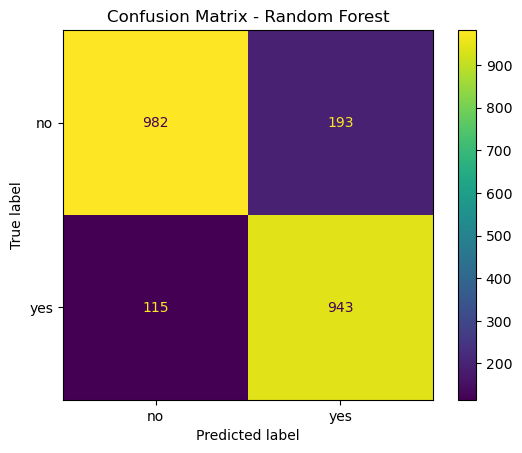

In [27]:
for name, pipeline in baseline_pipelines.items():
    y_pred = pipeline.predict(X_test)
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=label_encoder.classes_
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

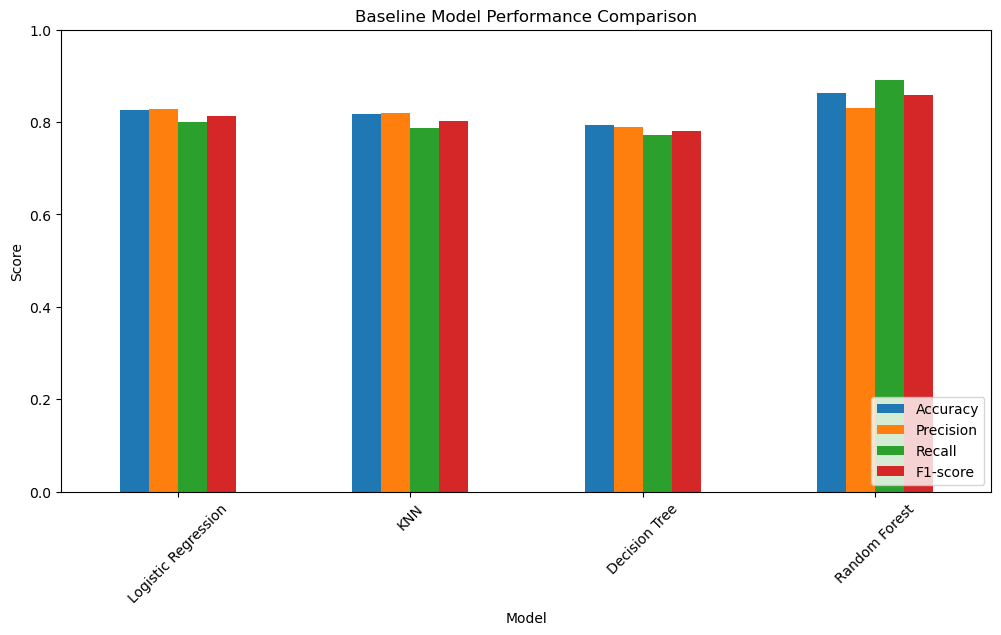

In [28]:
baseline_results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

In [29]:
# Feature Selection and Hyperparameter Tuning
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }


In [31]:
feature_selection_results = []

for k in [5, 10, 15, 20, 30]:
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("selector", SelectKBest(score_func=f_classif, k=k)),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    feature_selection_results.append({
        "Number of Features": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

feature_selection_df = pd.DataFrame(feature_selection_results)
feature_selection_df


,Number of Features,Accuracy,Precision,Recall,F1-score
0,5,0.778325,0.814525,0.689036,0.746544
1,10,0.789521,0.811441,0.724008,0.765235
2,15,0.816391,0.828600,0.772212,0.799413
3,20,0.819525,0.829146,0.779773,0.803702
4,30,0.824004,0.829534,0.791115,0.809869


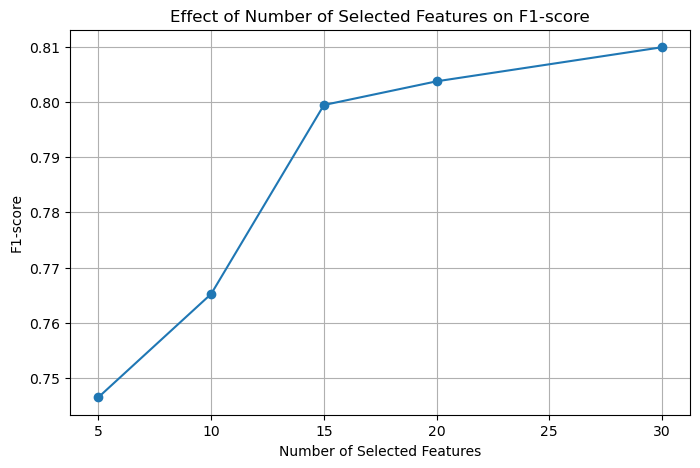

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    feature_selection_df["Number of Features"],
    feature_selection_df["F1-score"],
    marker="o"
)

plt.title("Effect of Number of Selected Features on F1-score")
plt.xlabel("Number of Selected Features")
plt.ylabel("F1-score")
plt.grid(True)
plt.show()


In [33]:
best_feature_selection = feature_selection_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

best_k = int(best_feature_selection["Number of Features"])

print("Best number of selected features:", best_k)
print("Best F1-score:", best_feature_selection["F1-score"])


Best number of selected features: 30
Best F1-score: 0.8098693759071117


In [34]:
## Feature Selection Discussion
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_params = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["liblinear", "lbfgs"]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)

print("Best parameters for Logistic Regression:")
print(log_reg_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(log_reg_grid.best_score_)


Best parameters for Logistic Regression:
{'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}

Best cross-validation F1-score:
0.8108344884187974


In [35]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

knn_params = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best parameters for KNN:")
print(knn_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(knn_grid.best_score_)


Best parameters for KNN:
{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}

Best cross-validation F1-score:
0.7865068787552851


In [36]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_params = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best parameters for Decision Tree:")
print(dt_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(dt_grid.best_score_)


Best parameters for Decision Tree:
{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best cross-validation F1-score:
0.79867784711684


In [37]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_params = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters for Random Forest:")
print(rf_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(rf_grid.best_score_)


Best parameters for Random Forest:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

Best cross-validation F1-score:
0.8473127566669136


In [38]:
tuning_summary = [
    {
        "Model": "Logistic Regression",
        "Tested Parameters": log_reg_params,
        "Best Parameters": log_reg_grid.best_params_,
        "Best CV F1-score": log_reg_grid.best_score_
    },
    {
        "Model": "KNN",
        "Tested Parameters": knn_params,
        "Best Parameters": knn_grid.best_params_,
        "Best CV F1-score": knn_grid.best_score_
    },
    {
        "Model": "Decision Tree",
        "Tested Parameters": dt_params,
        "Best Parameters": dt_grid.best_params_,
        "Best CV F1-score": dt_grid.best_score_
    },
    {
        "Model": "Random Forest",
        "Tested Parameters": rf_params,
        "Best Parameters": rf_grid.best_params_,
        "Best CV F1-score": rf_grid.best_score_
    }
]

tuning_summary_df = pd.DataFrame(tuning_summary)
tuning_summary_df


,Model,Tested Parameters,Best Parameters,Best CV F1-score
0,Logistic Regression,"{'classifier__C': [0.01, 0.1, 1, 10], 'classif...","{'classifier__C': 0.1, 'classifier__solver': '...",0.810834
1,KNN,"{'classifier__n_neighbors': [3, 5, 7, 9, 11], ...","{'classifier__metric': 'euclidean', 'classifie...",0.786507
2,Decision Tree,"{'classifier__criterion': ['gini', 'entropy'],...","{'classifier__criterion': 'gini', 'classifier_...",0.798678
3,Random Forest,"{'classifier__n_estimators': [50, 100, 200], '...","{'classifier__max_depth': None, 'classifier__m...",0.847313


In [39]:
tuned_models = {
    "Logistic Regression Tuned": log_reg_grid.best_estimator_,
    "KNN Tuned": knn_grid.best_estimator_,
    "Decision Tree Tuned": dt_grid.best_estimator_,
    "Random Forest Tuned": rf_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    result = evaluate_model(model, X_test, y_test, name)
    tuned_results.append(result)

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression Tuned,0.825795,0.825706,0.801512,0.813429
1,KNN Tuned,0.825795,0.834166,0.789225,0.811073
2,Decision Tree Tuned,0.816838,0.781440,0.851607,0.815016
3,Random Forest Tuned,0.857143,0.821584,0.892250,0.855460


In [40]:
comparison_baseline_tuned_df = pd.concat(
    [baseline_results_df, tuned_results_df],
    ignore_index=True
)

comparison_baseline_tuned_df.sort_values(by="F1-score", ascending=False)


,Model,Accuracy,Precision,Recall,F1-score
3,Random Forest,0.862069,0.830106,0.891304,0.859617
7,Random Forest Tuned,0.857143,0.821584,0.892250,0.855460
6,Decision Tree Tuned,0.816838,0.781440,0.851607,0.815016
0,Logistic Regression,0.826243,0.827789,0.799622,0.813462
4,Logistic Regression Tuned,0.825795,0.825706,0.801512,0.813429
5,KNN Tuned,0.825795,0.834166,0.789225,0.811073
1,KNN,0.817286,0.819882,0.787335,0.803279
2,Decision Tree,0.794447,0.789372,0.772212,0.780698


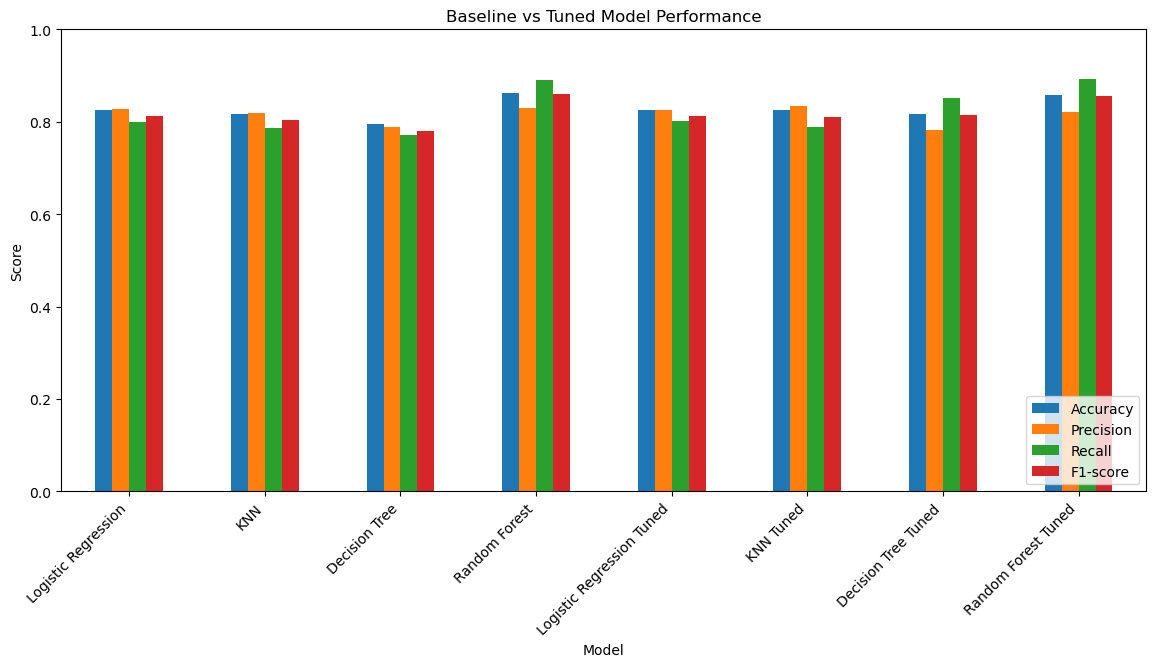

In [41]:
comparison_baseline_tuned_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Baseline vs Tuned Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.show()


In [42]:
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Logistic Regression Tuned
              precision    recall  f1-score   support

          no       0.83      0.85      0.84      1175
         yes       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.83      2233
weighted avg       0.83      0.83      0.83      2233

KNN Tuned
              precision    recall  f1-score   support

          no       0.82      0.86      0.84      1175
         yes       0.83      0.79      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233

Decision Tree Tuned
              precision    recall  f1-score   support

          no       0.85      0.79      0.82      1175
         yes       0.78      0.85      0.82      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg      

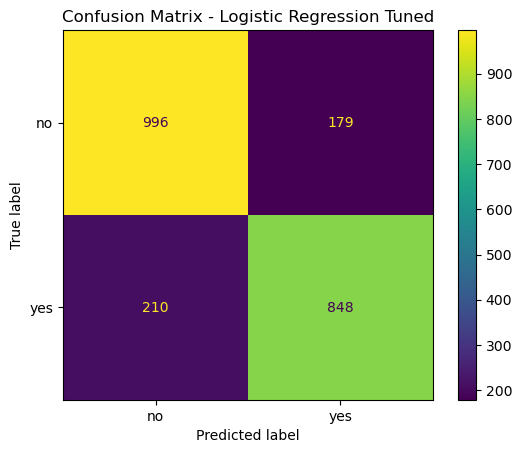

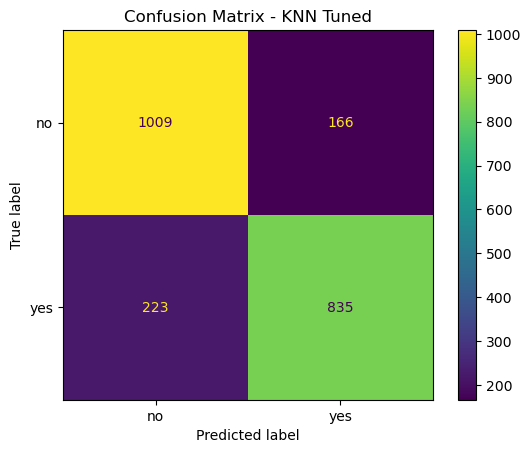

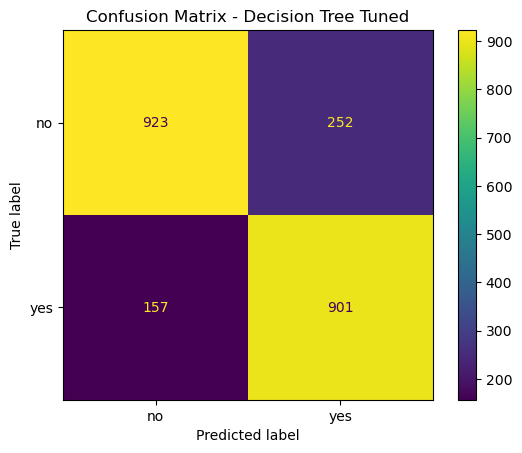

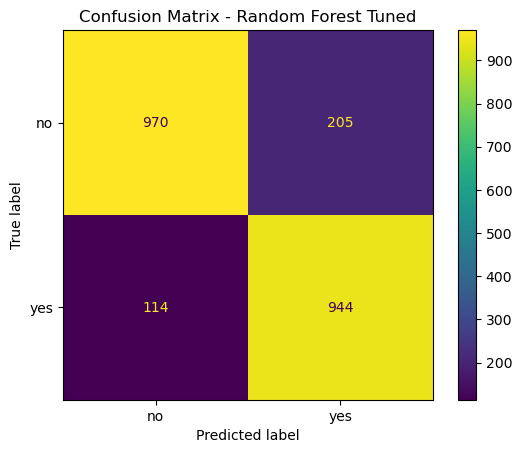

In [43]:
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=label_encoder.classes_
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


In [44]:
best_tuned_model_row = tuned_results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

best_tuned_model_row


Model        Random Forest Tuned
Accuracy                0.857143
Precision               0.821584
Recall                   0.89225
F1-score                 0.85546
Name: 3, dtype: object

In [45]:
# Neural Network, Clustering and Final Model Comparison

In [46]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [47]:
required_variables = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "X",
    "y",
    "y_encoded",
    "preprocessor",
    "label_encoder",
    "baseline_results_df",
    "tuned_results_df"
]

for variable in required_variables:
    if variable in globals():
        print(variable, "exists")
    else:
        print(variable, "is missing")

X_train exists
X_test exists
y_train exists
y_test exists
X exists
y exists
y_encoded exists
preprocessor exists
label_encoder exists
baseline_results_df exists
tuned_results_df exists


In [48]:
mlp_architecture_1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

mlp_architecture_1.fit(X_train, y_train)

y_pred_mlp_1 = mlp_architecture_1.predict(X_test)

print("Neural Network Architecture 1")
print("Hidden layers: (32,)")
print("Activation function: ReLU")
print(classification_report(y_test, y_pred_mlp_1, target_names=label_encoder.classes_))

Neural Network Architecture 1
Hidden layers: (32,)
Activation function: ReLU
              precision    recall  f1-score   support

          no       0.87      0.84      0.86      1175
         yes       0.83      0.86      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233



In [49]:
mlp_architecture_2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

mlp_architecture_2.fit(X_train, y_train)

y_pred_mlp_2 = mlp_architecture_2.predict(X_test)

print("Neural Network Architecture 2")
print("Hidden layers: (64, 32)")
print("Activation function: ReLU")
print(classification_report(y_test, y_pred_mlp_2, target_names=label_encoder.classes_))

Neural Network Architecture 2
Hidden layers: (64, 32)
Activation function: ReLU
              precision    recall  f1-score   support

          no       0.89      0.82      0.86      1175
         yes       0.82      0.89      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.86      0.86      0.85      2233
weighted avg       0.86      0.85      0.85      2233



In [50]:
mlp_architecture_3 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

mlp_architecture_3.fit(X_train, y_train)

y_pred_mlp_3 = mlp_architecture_3.predict(X_test)

print("Neural Network Architecture 3")
print("Hidden layers: (128, 64, 32)")
print("Activation function: ReLU")
print("Alpha: 0.001")
print(classification_report(y_test, y_pred_mlp_3, target_names=label_encoder.classes_))

Neural Network Architecture 3
Hidden layers: (128, 64, 32)
Activation function: ReLU
Alpha: 0.001
              precision    recall  f1-score   support

          no       0.91      0.81      0.86      1175
         yes       0.81      0.91      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



In [51]:
nn_results = [
    {
        "Model": "Neural Network (32)",
        "Accuracy": accuracy_score(y_test, y_pred_mlp_1),
        "Precision": precision_score(y_test, y_pred_mlp_1),
        "Recall": recall_score(y_test, y_pred_mlp_1),
        "F1-score": f1_score(y_test, y_pred_mlp_1)
    },
    {
        "Model": "Neural Network (64, 32)",
        "Accuracy": accuracy_score(y_test, y_pred_mlp_2),
        "Precision": precision_score(y_test, y_pred_mlp_2),
        "Recall": recall_score(y_test, y_pred_mlp_2),
        "F1-score": f1_score(y_test, y_pred_mlp_2)
    },
    {
        "Model": "Neural Network (128, 64, 32)",
        "Accuracy": accuracy_score(y_test, y_pred_mlp_3),
        "Precision": precision_score(y_test, y_pred_mlp_3),
        "Recall": recall_score(y_test, y_pred_mlp_3),
        "F1-score": f1_score(y_test, y_pred_mlp_3)
    }
]

nn_results_df = pd.DataFrame(nn_results)

nn_results_df.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
2,"Neural Network (128, 64, 32)",0.855799,0.811337,0.906427,0.856250
1,"Neural Network (64, 32)",0.854008,0.818815,0.888469,0.852221
0,Neural Network (32),0.851769,0.831358,0.862004,0.846404


In [52]:
best_nn_model = nn_results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

print("Best Neural Network architecture:")
best_nn_model

Best Neural Network architecture:


Model        Neural Network (128, 64, 32)
Accuracy                         0.855799
Precision                        0.811337
Recall                           0.906427
F1-score                          0.85625
Name: 2, dtype: object

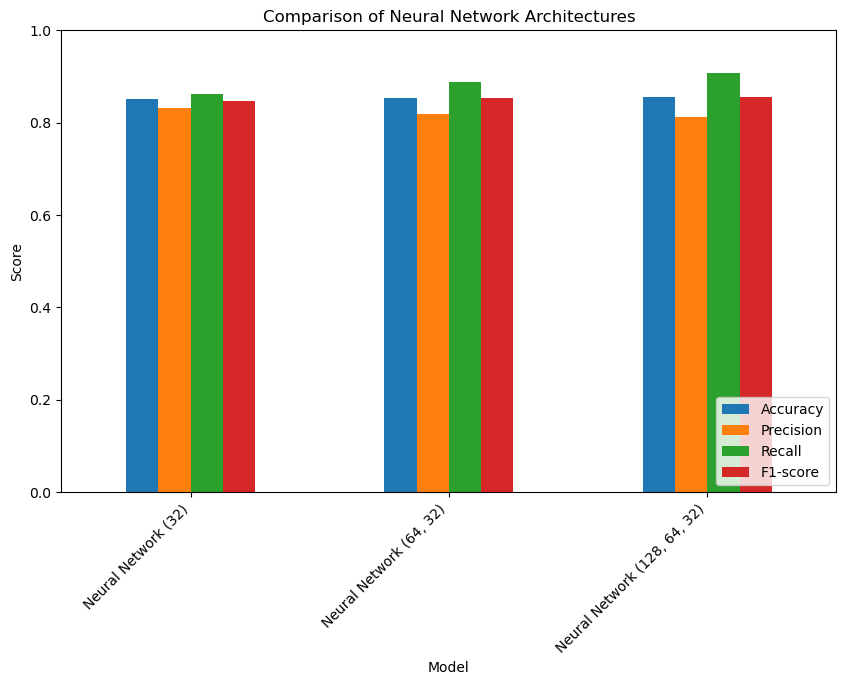

In [53]:
nn_results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Neural Network Architectures")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.show()

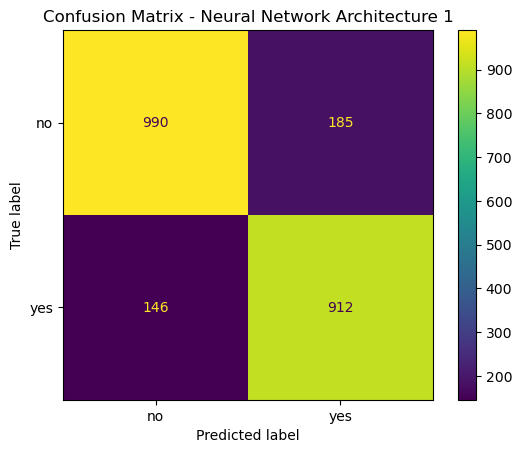

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp_1,
    display_labels=label_encoder.classes_
)

plt.title("Confusion Matrix - Neural Network Architecture 1")
plt.show()

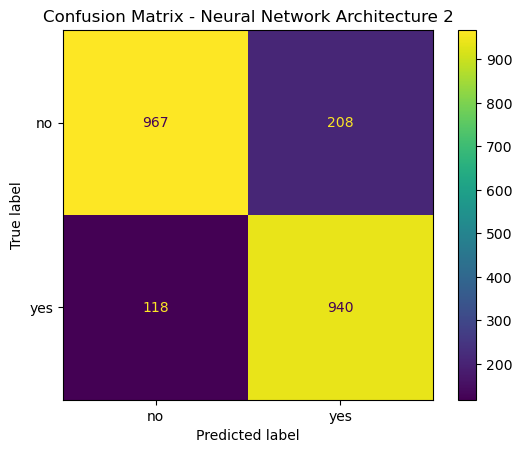

In [55]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp_2,
    display_labels=label_encoder.classes_
)

plt.title("Confusion Matrix - Neural Network Architecture 2")
plt.show()

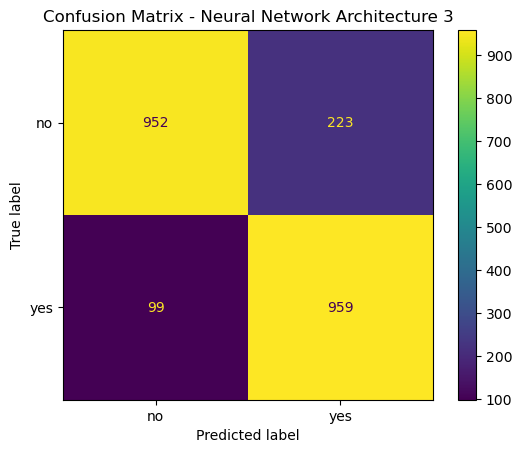

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp_3,
    display_labels=label_encoder.classes_
)

plt.title("Confusion Matrix - Neural Network Architecture 3")
plt.show()

In [57]:
# Clustering with KMeans


In [58]:
X_clustering = X.copy()

X_clustering_processed = preprocessor.fit_transform(X_clustering)

print("Original clustering data shape:", X_clustering.shape)
print("Processed clustering data shape:", X_clustering_processed.shape)

Original clustering data shape: (11162, 16)
Processed clustering data shape: (11162, 51)


In [59]:
clustering_results = []

for k in [2, 3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_clustering_processed)
    
    ari = adjusted_rand_score(y_encoded, cluster_labels)
    nmi = normalized_mutual_info_score(y_encoded, cluster_labels)
    
    clustering_results.append({
        "Number of Clusters": k,
        "Adjusted Rand Index": ari,
        "Normalized Mutual Information": nmi,
        "Inertia": kmeans.inertia_
    })

clustering_results_df = pd.DataFrame(clustering_results)
clustering_results_df

,Number of Clusters,Adjusted Rand Index,Normalized Mutual Information,Inertia
0,2,0.047272,0.040814,113017.783351
1,3,0.022652,0.019815,106057.226957
2,4,0.017975,0.022036,100115.764474
3,5,0.069386,0.076484,94695.245708


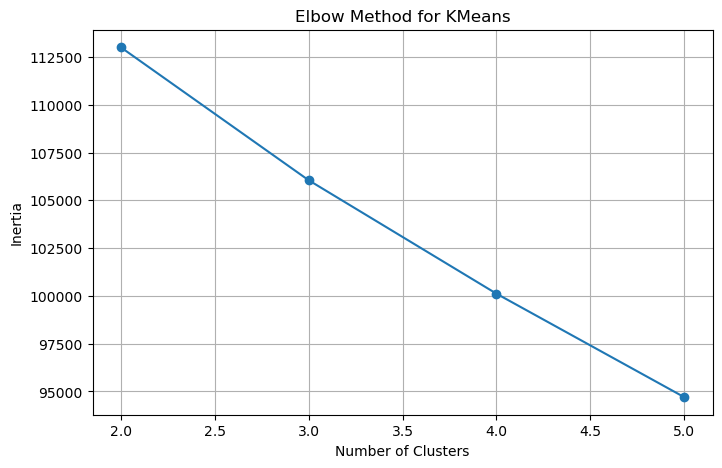

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    clustering_results_df["Number of Clusters"],
    clustering_results_df["Inertia"],
    marker="o"
)

plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [61]:
silhouette_results = []

for k in [2, 3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_clustering_processed)
    
    score = silhouette_score(X_clustering_processed, cluster_labels)
    
    silhouette_results.append({
        "Number of Clusters": k,
        "Silhouette Score": score
    })

silhouette_results_df = pd.DataFrame(silhouette_results)
silhouette_results_df

,Number of Clusters,Silhouette Score
0,2,0.178548
1,3,0.102555
2,4,0.107396
3,5,0.105464


In [62]:
clustering_evaluation_df = clustering_results_df.merge(
    silhouette_results_df,
    on="Number of Clusters"
)

clustering_evaluation_df

,Number of Clusters,Adjusted Rand Index,Normalized Mutual Information,Inertia,Silhouette Score
0,2,0.047272,0.040814,113017.783351,0.178548
1,3,0.022652,0.019815,106057.226957,0.102555
2,4,0.017975,0.022036,100115.764474,0.107396
3,5,0.069386,0.076484,94695.245708,0.105464


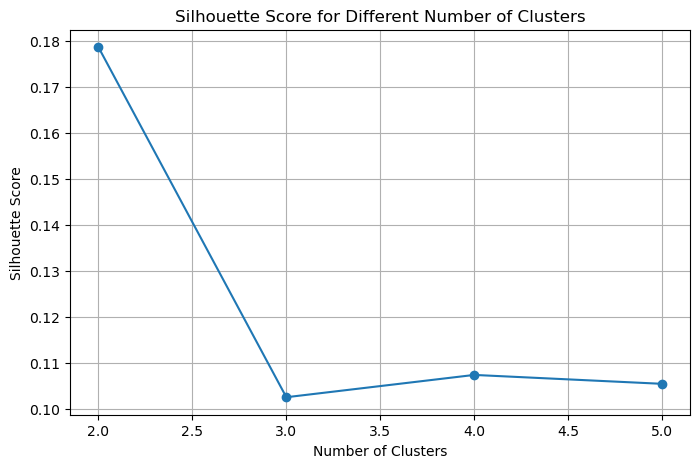

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(
    clustering_evaluation_df["Number of Clusters"],
    clustering_evaluation_df["Silhouette Score"],
    marker="o"
)

plt.title("Silhouette Score for Different Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [64]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters_2 = kmeans_2.fit_predict(X_clustering_processed)

print("Cluster labels distribution:")
print(pd.Series(clusters_2).value_counts())

Cluster labels distribution:
0    8443
1    2719
Name: count, dtype: int64


In [65]:
if hasattr(X_clustering_processed, "toarray"):
    X_clustering_dense = X_clustering_processed.toarray()
else:
    X_clustering_dense = X_clustering_processed

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_clustering_dense)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.15412121 0.10764132]


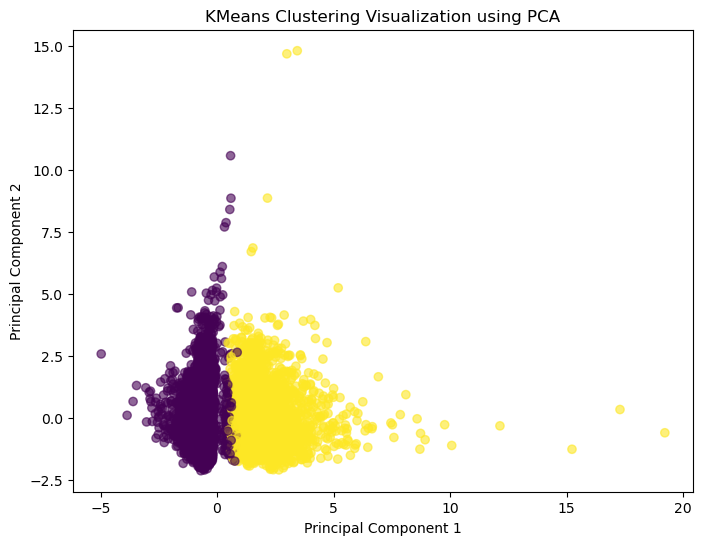

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_2,
    alpha=0.6
)

plt.title("KMeans Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

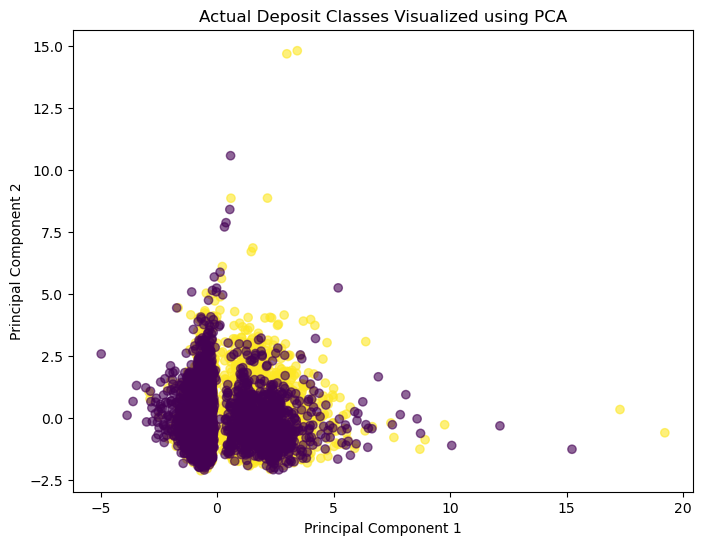

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_encoded,
    alpha=0.6
)

plt.title("Actual Deposit Classes Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [68]:
cluster_comparison = pd.crosstab(
    pd.Series(y, name="Actual Deposit"),
    pd.Series(clusters_2, name="Cluster")
)

cluster_comparison

Cluster,0,1
Actual Deposit,,
no,4979,894
yes,3464,1825


In [69]:
ari_k2 = adjusted_rand_score(y_encoded, clusters_2)
nmi_k2 = normalized_mutual_info_score(y_encoded, clusters_2)
silhouette_k2 = silhouette_score(X_clustering_processed, clusters_2)

print("Adjusted Rand Index for k=2:", ari_k2)
print("Normalized Mutual Information for k=2:", nmi_k2)
print("Silhouette Score for k=2:", silhouette_k2)

Adjusted Rand Index for k=2: 0.04727215585246527
Normalized Mutual Information for k=2: 0.040814264509718416
Silhouette Score for k=2: 0.17854845801143515


In [70]:
# Final Model Comparison

In [71]:
final_results_df = pd.concat(
    [
        baseline_results_df,
        tuned_results_df,
        nn_results_df
    ],
    ignore_index=True
)

final_results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.826243,0.827789,0.799622,0.813462
1,KNN,0.817286,0.819882,0.787335,0.803279
2,Decision Tree,0.794447,0.789372,0.772212,0.780698
3,Random Forest,0.862069,0.830106,0.891304,0.859617
4,Logistic Regression Tuned,0.825795,0.825706,0.801512,0.813429
5,KNN Tuned,0.825795,0.834166,0.789225,0.811073
6,Decision Tree Tuned,0.816838,0.781440,0.851607,0.815016
7,Random Forest Tuned,0.857143,0.821584,0.892250,0.855460
8,Neural Network (32),0.851769,0.831358,0.862004,0.846404
9,"Neural Network (64, 32)",0.854008,0.818815,0.888469,0.852221


In [72]:
final_results_sorted_df = final_results_df.sort_values(
    by="F1-score",
    ascending=False
)

final_results_sorted_df

,Model,Accuracy,Precision,Recall,F1-score
3,Random Forest,0.862069,0.830106,0.891304,0.859617
10,"Neural Network (128, 64, 32)",0.855799,0.811337,0.906427,0.856250
7,Random Forest Tuned,0.857143,0.821584,0.892250,0.855460
9,"Neural Network (64, 32)",0.854008,0.818815,0.888469,0.852221
8,Neural Network (32),0.851769,0.831358,0.862004,0.846404
6,Decision Tree Tuned,0.816838,0.781440,0.851607,0.815016
0,Logistic Regression,0.826243,0.827789,0.799622,0.813462
4,Logistic Regression Tuned,0.825795,0.825706,0.801512,0.813429
5,KNN Tuned,0.825795,0.834166,0.789225,0.811073
1,KNN,0.817286,0.819882,0.787335,0.803279


In [73]:
best_final_model = final_results_sorted_df.iloc[0]

print("Best final model:")
best_final_model

Best final model:


Model        Random Forest
Accuracy          0.862069
Precision         0.830106
Recall            0.891304
F1-score          0.859617
Name: 3, dtype: object

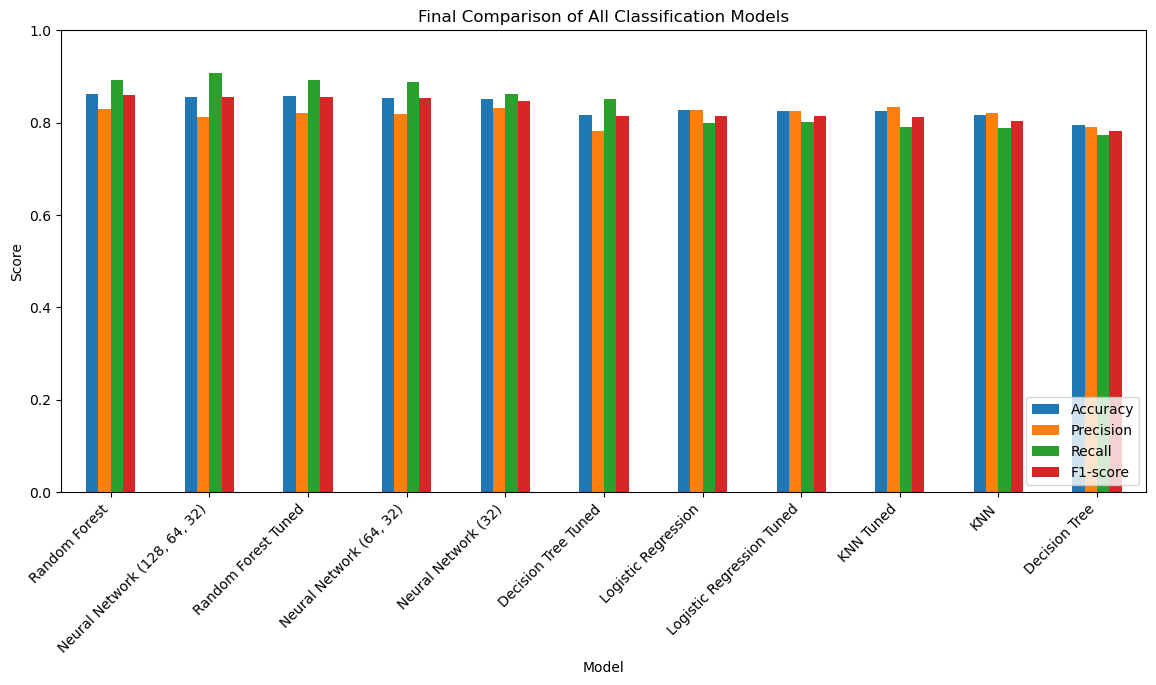

In [74]:
final_results_sorted_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Final Comparison of All Classification Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.show()